# BNY Corporate-Actions EDA — Datastore → Notification MVP

**Product question:** How much of a real BNY client notification can we reconstruct from public corporate-action documents — with citations and amendment history?

**MVP event types (BNY-aligned):**
1. Tender offers
2. Exchange offers
3. Rights issues
4. Mergers
5. Conversions

**Pipeline this EDA supports:**
```text
Public SEC docs
    → versioned event datastore
    → field extraction + evidence
    → BNY-shaped notification draft
    → amendment / cancellation deltas
```

**Evidence discipline:** Observed (metadata/download) · Inferred (regex mention ≠ extraction) · Internal (BNY-only) · Gap (event type not yet collected).

> Current corpus is **tender-centric** (SC TO-* + SC 14D9). Coverage % for rights / merger / conversion are **not invented** — they appear as corpus gaps until those forms are collected.


In [17]:
from pathlib import Path
import sys, warnings, importlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 120)
sns.set_theme(style='whitegrid')

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
SRC = str(ROOT / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

# Reload submodules so long-lived notebook kernels pick up code edits.
import eda.event_taxonomy as _event_taxonomy
import eda.bny_schema as _bny_schema
import eda.mvp as _mvp
import eda.mvp_viz as _mvp_viz
for _mod in (_event_taxonomy, _bny_schema, _mvp, _mvp_viz):
    importlib.reload(_mod)

from eda.corpus import load_corpus
from eda.overview import summarize_dataset, overview_tables
from eda.events import analyze_events
from eda.documents import analyze_documents, sample_documents_for_content
from eda.schema_coverage import analyze_schema_coverage
from eda.amendments import analyze_amendments
from eda.quality import analyze_data_quality
from eda.missingness import classify_missingness, ground_truth_recommendations
from eda.mvp import BENCHMARK_FIELDS_V1, recommend_mvp_design
from eda.mvp_viz import (
    plot_benchmark_field_coverage,
    plot_event_family_mix,
    plot_event_type_coverage_heatmap,
    plot_event_type_field_relevance_matrix,
    plot_field_ownership_counts,
    plot_mvp_amendment_readiness,
    plot_mvp_event_type_readiness,
    plot_mvp_selection_funnel,
    plot_notification_completeness,
    plot_schema_coverage_by_ownership,
)
from eda.event_taxonomy import MVP_EVENT_TYPES, taxonomy_overview_table
from eda.bny_schema import BNY_SCHEMA
from eda.config import PROCESSED_DIR, FIGURES_DIR

OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
(OUTPUTS / 'figures').mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('BNY schema fields:', len(BNY_SCHEMA))
print('MVP event types:', [t.key for t in MVP_EVENT_TYPES])
print('Benchmark fields:', BENCHMARK_FIELDS_V1)


BNY schema fields: 39
MVP event types: ['tender_offer', 'exchange_offer', 'rights_issue', 'merger', 'conversion']
Benchmark fields: ['corporate_action_type', 'security_description', 'cusip', 'ticker', 'election_deadline', 'response_deadline', 'notification_status', 'available_options', 'conversion_ratio', 'cash_amount']


## 0. Target event taxonomy (design)

What each MVP type is, which SEC forms feed the datastore, and whether we have them yet.


In [18]:
tax = taxonomy_overview_table()
display(tax)
tax.to_csv(OUTPUTS / 'mvp_event_taxonomy.csv', index=False)


,mvp_event_type,label,bny_corporate_action_type,corpus_status,primary_sec_forms,supporting_sec_forms,notes
0,tender_offer,Tender offer,TENDER OFFER,collected,"SC TO-T, SC TO-T/A, SC TO-I, SC TO-I/A","SC 14D9, SC 14D9/A",Primary corpus today. Prefer third-party + 14D9 mixed events for MVP v1.
1,exchange_offer,Exchange offer,EXCHANGE,partial_in_tender_corpus,"SC TO-T, SC TO-T/A, SC TO-I, SC TO-I/A, S-4, S-4/A","SC 14D9, SC 14D9/A, 424B3, 8-K","Some exchange offers already sit inside Schedule TO filings and can be flagged via narrative ('exchange offer', exch..."
2,rights_issue,Rights issue,RIGHTS ISSUE,not_collected,"424B2, 424B3, 424B5, S-3, S-3ASR","8-K, 424B4",Not in current EFTS tender extract. Next corpus expansion priority after tender/exchange.
3,merger,Merger,MERGER,not_collected,"DEFM14A, PREM14A, S-4, S-4/A, SC 13E-3, SC 13E-3/A","8-K, 425",High value for election/options extraction; requires proxy/S-4 corpus build.
4,conversion,Conversion,CONVERSION,not_collected,"8-K, 424B2, 424B3, S-3, S-3ASR","10-K, 10-Q",Sparse structured SEC form; often narrative in 8-K / prospectus. Needs targeted collection.


## 1. Load corpus + honest readiness gaps

Raw EFTS **hit counts by form** inflate exhibits. Prefer **event-level** views for MVP selection.


,metric,value
0,documents,32046
1,filings (unique accession),9364
2,events (by SEC file number),893
3,date_min,2020-01-02
4,date_max,2025-12-31
5,events_with_amendments,870
6,pct_events_with_amendments,97.42


,form,n_documents
0,SC TO-I,17893
1,SC TO-I/A,6495
2,SC TO-T,2844
3,SC TO-T/A,2388
4,SC 14D9/A,1474
5,SC 14D9,952


Document rows are EFTS hit-level records (primary filing docs + indexed exhibits). Events are grouped by SEC file number (primary_file_num) when present.


,mvp_event_type,label,corpus_status,primary_forms_in_corpus,supporting_forms_in_corpus,missing_primary_forms,n_primary_forms_present,n_primary_forms_target,primary_form_coverage_pct
0,tender_offer,Tender offer,collected,"SC TO-I, SC TO-I/A, SC TO-T, SC TO-T/A","SC 14D9, SC 14D9/A",(none),4,4,100.0
1,exchange_offer,Exchange offer,partial_in_tender_corpus,"SC TO-I, SC TO-I/A, SC TO-T, SC TO-T/A","SC 14D9, SC 14D9/A","S-4, S-4/A",4,6,66.7
2,rights_issue,Rights issue,not_collected,(none),(none),"424B2, 424B3, 424B5, S-3, S-3ASR",0,5,0.0
3,merger,Merger,not_collected,(none),(none),"DEFM14A, PREM14A, S-4, S-4/A, SC 13E-3, SC 13E-3/A",0,6,0.0
4,conversion,Conversion,not_collected,(none),(none),"424B2, 424B3, 8-K, S-3, S-3ASR",0,5,0.0


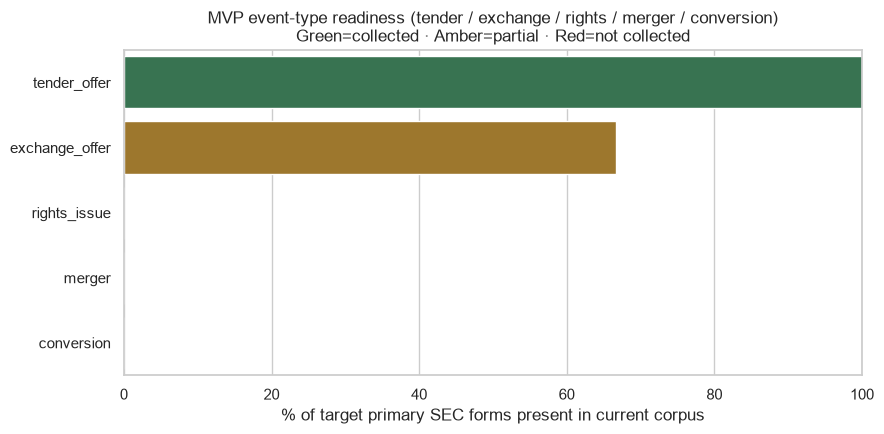

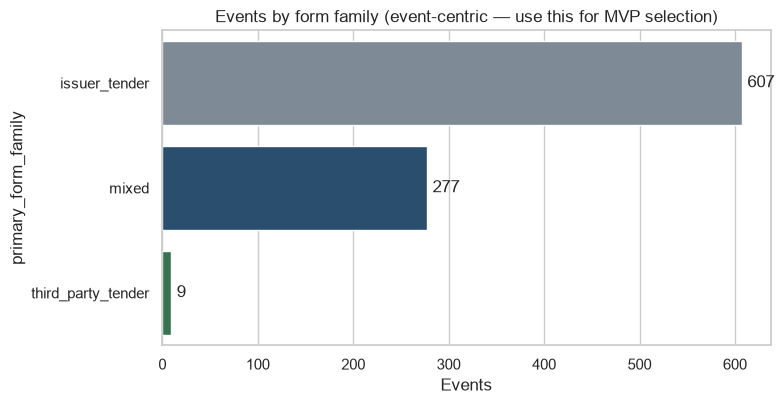

In [19]:
docs, events = load_corpus()
overview = summarize_dataset(docs, events)
tables = overview_tables(docs, events)
display(tables['summary'])
display(tables['form_counts'])
print(overview['source_note'])

mvp = recommend_mvp_design(docs, events)  # preliminary; refreshed after coverage
display(mvp['corpus_gaps'])
fig = plot_mvp_event_type_readiness(mvp['corpus_gaps']); plt.show()
fig = plot_event_family_mix(events); plt.show()


## 2. Datastore selection funnel (executable v1 = tenders)

Until exchange / rights / merger / conversion forms are collected, the **executable** MVP pool is third-party tenders (preferably with 14D9).


,stage,n_events
0,all_events_in_corpus,893
1,has_sec_file_num,893
2,tender_mvp_core_to_t,285
3,tender_preferred_to_t_plus_14d9,272
4,tender_preferred_with_amendments,271
5,issuer_tender_stretch_to_i_only,608


,phase,mvp_event_type,action,corpus_ready
0,1,tender_offer,Build event datastore + extraction + notification draft on SC TO-T + 14D9,True
1,2,exchange_offer,Reclassify exchange language inside TO; add S-4 collection,False
2,3,merger,Collect DEFM14A / S-4 / SC 13E-3; election-options benchmark,False
3,4,rights_issue,Collect 424B* / S-3 rights offerings; record/ex/subscription fields,False
4,5,conversion,Collect 8-K / prospectus conversion notices; ratio/price benchmark,False


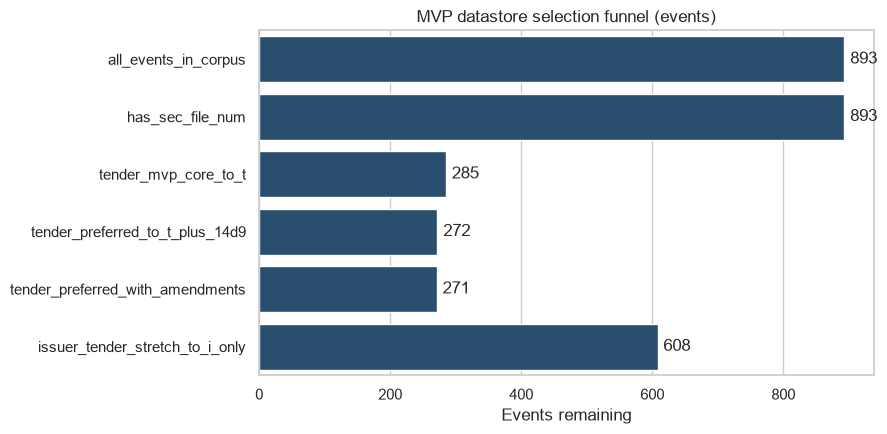

In [20]:
display(mvp['funnel'])
display(mvp['build_order'])
fig = plot_mvp_selection_funnel(mvp['funnel']); plt.show()
mvp['funnel'].to_csv(OUTPUTS / 'mvp_selection_funnel.csv', index=False)
mvp['build_order'].to_csv(OUTPUTS / 'mvp_build_order.csv', index=False)


## 3. Which BNY fields matter per event type

Design prior (not empirical coverage). Use this to shape the **event datastore columns** and per-type notification templates.


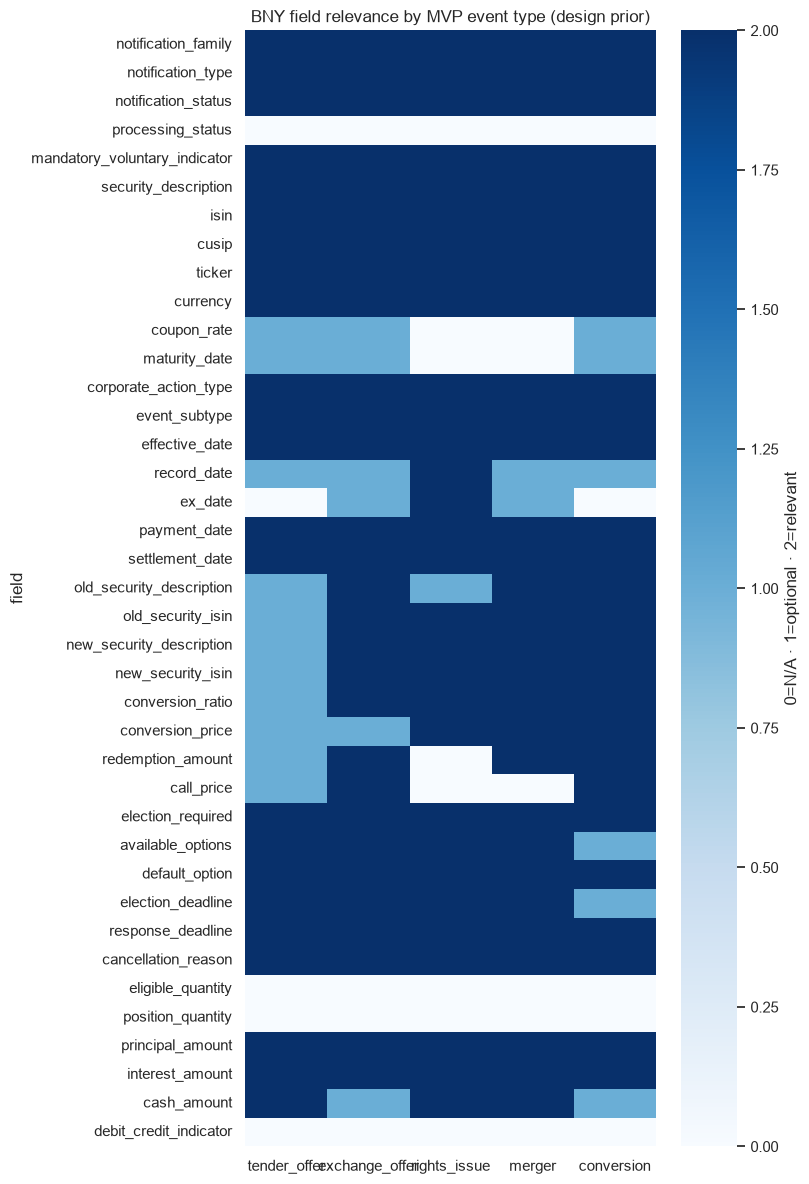

In [21]:
fig = plot_event_type_field_relevance_matrix(); plt.show()


## 4. Schema coverage from public docs (tender corpus)

Text % = regex **mention** on downloaded sample — not extraction accuracy. Internal fields stay 0% by definition.


form       status
SC 14D9    ok        10
SC 14D9/A  ok        10
SC TO-I    ok        10
SC TO-I/A  ok        10
SC TO-T    ok        10
SC TO-T/A  ok        10
dtype: int64
Text-field coverage percentages are inferred from regex presence on downloaded sample documents covering 38 events. They measure mention detection, not successful structured extraction. Internal-only fields are definitionally 0% public coverage.


,field,source_class,datastore_role,in_v1_benchmark,public_coverage_pct,relevant_mvp_types
0,notification_family,derived_from_public,derive_from_public,False,100.00,"tender_offer,exchange_offer,rights_issue,merger,conversion"
1,notification_type,derived_from_public,annotate_then_store,False,73.68,"tender_offer,exchange_offer,rights_issue,merger,conversion"
2,notification_status,derived_from_public,derive_from_public,True,97.37,"tender_offer,exchange_offer,rights_issue,merger,conversion"
3,processing_status,bny_internal_only,bny_placeholder,False,0.00,
4,mandatory_voluntary_indicator,public_document_extractable,annotate_then_store,False,5.26,"tender_offer,exchange_offer,rights_issue,merger,conversion"
5,security_description,public_document_extractable,extract_from_public,True,100.00,"tender_offer,exchange_offer,rights_issue,merger,conversion"
6,isin,public_document_extractable,annotate_then_store,False,0.00,"tender_offer,exchange_offer,rights_issue,merger,conversion"
7,cusip,public_document_extractable,annotate_then_store,True,97.37,"tender_offer,exchange_offer,rights_issue,merger,conversion"
8,ticker,public_document_extractable,extract_from_public,True,51.18,"tender_offer,exchange_offer,rights_issue,merger,conversion"
9,currency,public_document_extractable,extract_from_public,False,13.16,"tender_offer,exchange_offer,rights_issue,merger,conversion"


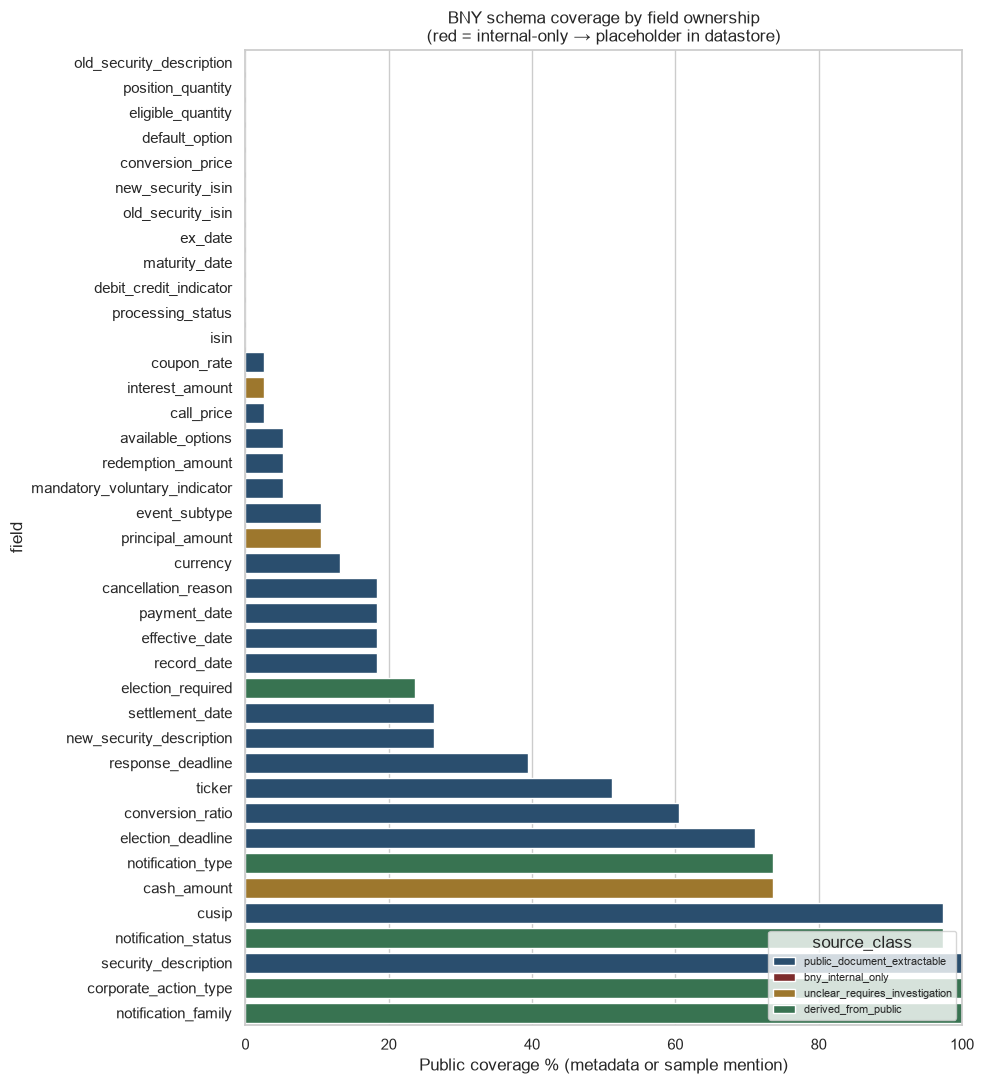

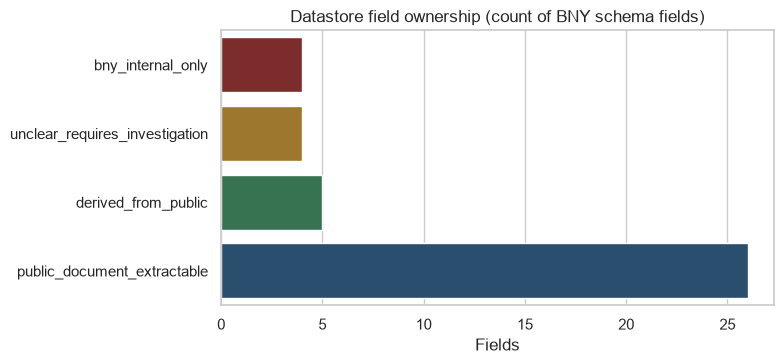

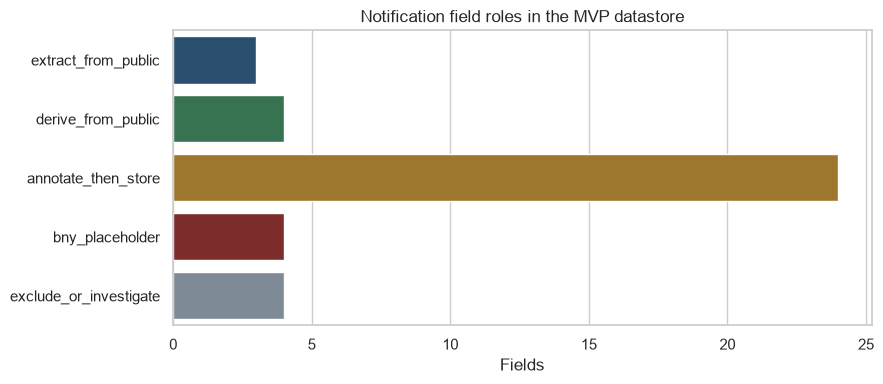

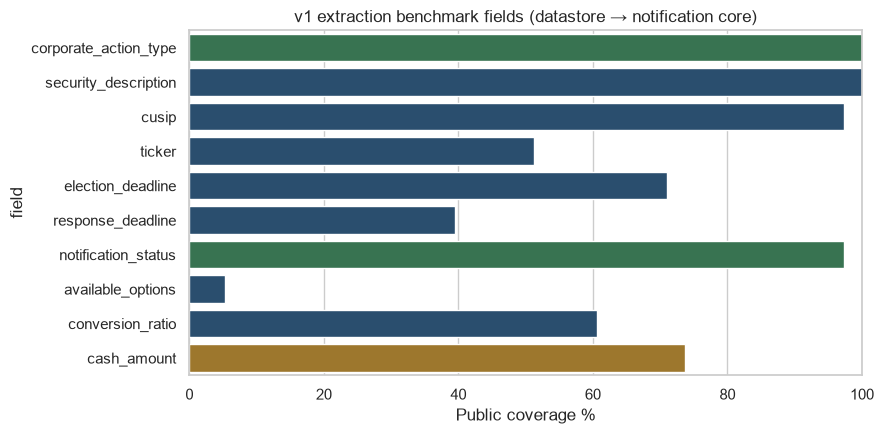

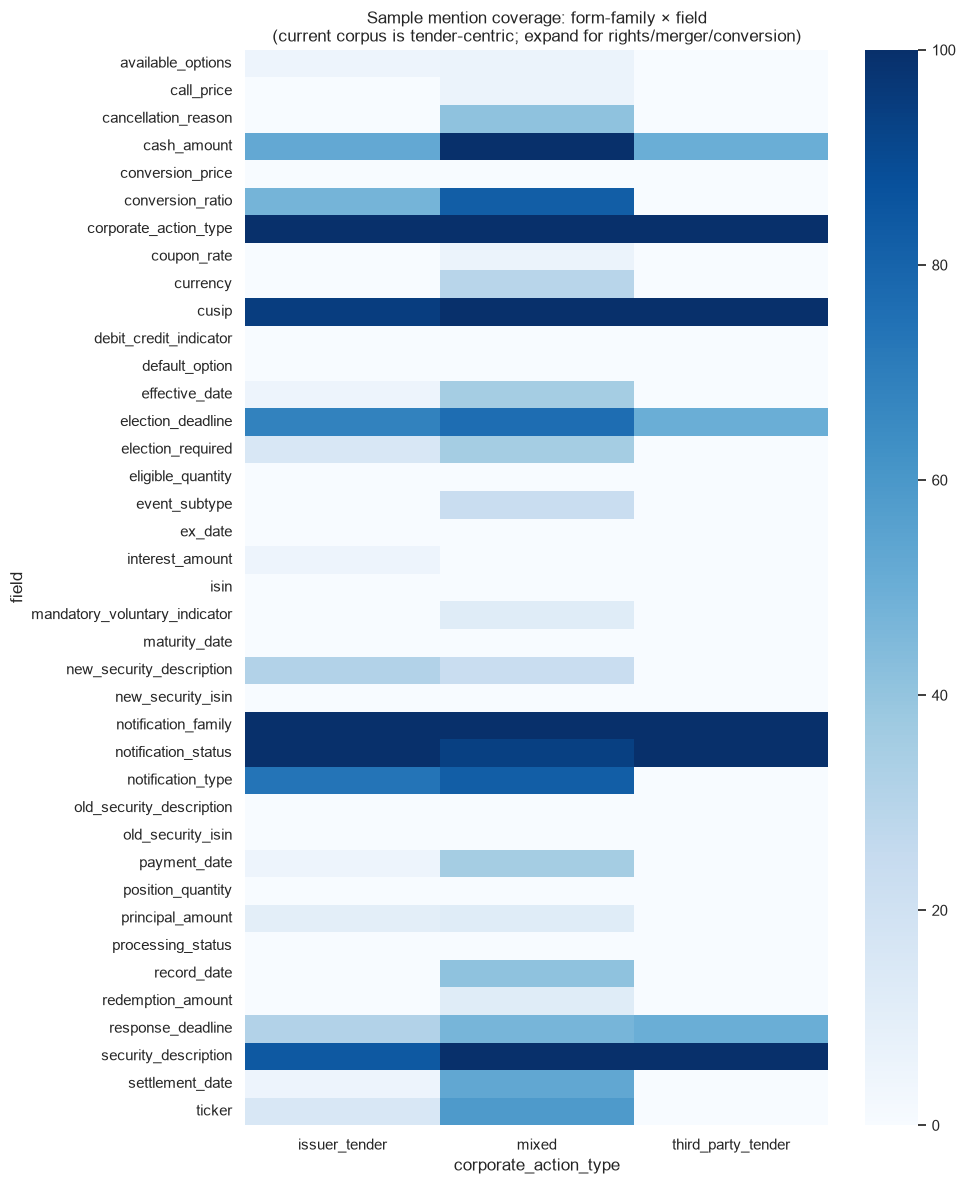

In [22]:
sample_path = PROCESSED_DIR / 'content_sample.parquet'
if sample_path.exists():
    content_sample = pd.read_parquet(sample_path)
else:
    content_sample = sample_documents_for_content(docs, n_per_form=10)
    content_sample.to_parquet(sample_path, index=False)

print(content_sample.groupby(['form','status']).size())
coverage = analyze_schema_coverage(docs, events, content_sample)
print(coverage['note'])

mvp = recommend_mvp_design(docs, events, coverage['schema_coverage'])
catalog = mvp['datastore_field_catalog']
display(catalog[['field','source_class','datastore_role','in_v1_benchmark','public_coverage_pct','relevant_mvp_types']])

fig = plot_schema_coverage_by_ownership(coverage['schema_coverage']); plt.show()
fig = plot_field_ownership_counts(coverage['schema_coverage']); plt.show()
fig = plot_notification_completeness(catalog); plt.show()
fig = plot_benchmark_field_coverage(coverage['schema_coverage'], BENCHMARK_FIELDS_V1); plt.show()
fig = plot_event_type_coverage_heatmap(coverage['event_type_coverage']); plt.show()


## 5. Temporal / amendment readiness (versioned event history)

Lifecycle: `initial → amendment(s) → completed/cancelled` — never overwrite prior versions.


Events with amendments: 870 (97.42%)
MVP preferred events: 272 | simple amend eval: 104 | complex: 177


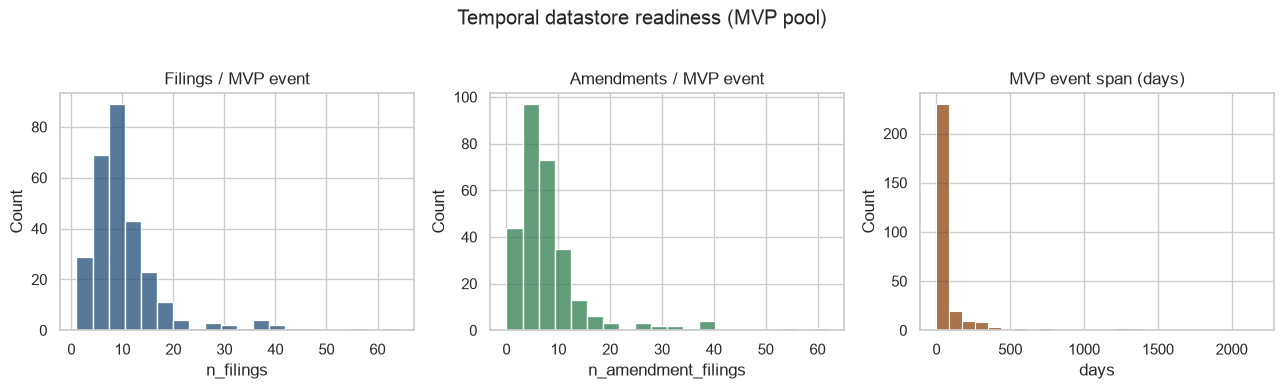

,event_id,primary_entity,primary_form_family,mvp_event_type_provisional,n_filings,n_amendment_filings,n_documents,event_span_days,has_14d9,in_mvp_preferred,amendment_eval_band
0,005-02933,"VOLT INFORMATION SCIENCES, INC.",mixed,tender_offer,10,8,23,31,True,True,complex
1,005-06295,VECTOR GROUP LTD,mixed,tender_offer,9,7,21,33,True,True,complex
3,005-09319,AVX Corp,mixed,tender_offer,7,5,17,28,True,True,simple
4,005-09915,EVANS & SUTHERLAND COMPUTER CORP,mixed,tender_offer,8,5,28,45,True,True,simple
5,005-12061,HP INC,mixed,tender_offer,7,4,18,35,True,True,simple
8,005-12857,"ADAMS NATURAL RESOURCES FUND, INC.",mixed,tender_offer,14,9,49,118,True,True,complex
9,005-18240,CSS INDUSTRIES INC,mixed,tender_offer,11,9,27,31,True,True,complex
13,005-20723,CONTINENTAL MATERIALS CORP,mixed,tender_offer,14,11,37,62,True,True,complex
18,005-30797,OVERSEAS SHIPHOLDING GROUP INC,mixed,tender_offer,9,7,43,30,True,True,complex
20,005-31632,GOLDFIELD CORP,mixed,tender_offer,17,15,37,29,True,True,complex


In [23]:
amend = analyze_amendments(docs, events, content_sample)
print(f"Events with amendments: {amend['n_events_with_amendments']} ({amend['pct_events_with_amendments']}%)")
print(f"MVP preferred events: {mvp['mvp_preferred_count']} | simple amend eval: {mvp['amendment_eval_simple_count']} | complex: {mvp['amendment_eval_complex_count']}")
fig = plot_mvp_amendment_readiness(mvp['mvp_events']); plt.show()
display(mvp['mvp_events_preview'])


## 6. Ground-truth & missingness (for the notification datastore)

Do not treat all missing values the same: N/A vs absent vs parse gap vs BNY-internal.


In [24]:
miss = classify_missingness(coverage['schema_coverage'], coverage['event_type_coverage'])
gt = ground_truth_recommendations(coverage['schema_coverage'])
display(miss.head(40))
display(catalog[catalog['in_v1_benchmark']][['field','datastore_role','ground_truth_class','public_coverage_pct','relevant_mvp_types']])
display(gt.head(25))
print('Manual annotation priorities:')
for p in mvp['manual_annotation_priorities']:
    print(' -', p)


,field,group,public_coverage_pct,missingness_class,source_class,ground_truth_class,evidence_type
0,notification_family,notification_metadata,100.00,usually_present_in_public_sample,derived_from_public,weak_heuristic,inferred_regex_presence
1,notification_type,notification_metadata,73.68,sometimes_present_in_public_sample,derived_from_public,requires_manual_annotation,inferred_regex_presence
2,notification_status,notification_metadata,97.37,usually_present_in_public_sample,derived_from_public,weak_heuristic,inferred_regex_presence
3,processing_status,notification_metadata,0.00,internal_bny_only,bny_internal_only,cannot_evaluate_from_public,internal_only
4,mandatory_voluntary_indicator,notification_metadata,5.26,likely_relevant_but_rarely_detected,public_document_extractable,requires_manual_annotation,inferred_regex_presence
5,security_description,security,100.00,usually_present_in_public_sample,public_document_extractable,weak_heuristic,observed_metadata
6,isin,security,0.00,likely_relevant_but_rarely_detected,public_document_extractable,requires_manual_annotation,inferred_regex_presence
7,cusip,security,97.37,usually_present_in_public_sample,public_document_extractable,requires_manual_annotation,inferred_regex_presence
8,ticker,security,51.18,sometimes_present_in_public_sample,public_document_extractable,weak_heuristic,observed_metadata
9,currency,security,13.16,likely_relevant_but_rarely_detected,public_document_extractable,weak_heuristic,inferred_regex_presence


,field,datastore_role,ground_truth_class,public_coverage_pct,relevant_mvp_types
2,notification_status,derive_from_public,weak_heuristic,97.37,"tender_offer,exchange_offer,rights_issue,merger,conversion"
5,security_description,extract_from_public,weak_heuristic,100.00,"tender_offer,exchange_offer,rights_issue,merger,conversion"
7,cusip,annotate_then_store,requires_manual_annotation,97.37,"tender_offer,exchange_offer,rights_issue,merger,conversion"
8,ticker,extract_from_public,weak_heuristic,51.18,"tender_offer,exchange_offer,rights_issue,merger,conversion"
12,corporate_action_type,derive_from_public,strong_automatic,100.00,"tender_offer,exchange_offer,rights_issue,merger,conversion"
23,conversion_ratio,annotate_then_store,requires_manual_annotation,60.53,"tender_offer,exchange_offer,rights_issue,merger,conversion"
28,available_options,annotate_then_store,requires_manual_annotation,5.26,"tender_offer,exchange_offer,rights_issue,merger,conversion"
30,election_deadline,annotate_then_store,requires_manual_annotation,71.05,"tender_offer,exchange_offer,rights_issue,merger,conversion"
31,response_deadline,annotate_then_store,requires_manual_annotation,39.47,"tender_offer,exchange_offer,rights_issue,merger,conversion"
37,cash_amount,exclude_or_investigate,cannot_evaluate_from_public,73.68,"tender_offer,exchange_offer,rights_issue,merger,conversion"


,field,group,public_coverage_pct,ground_truth_class,difficulty,benchmark_recommendation,evidence_type
26,call_price,conversion_exchange,2.63,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
24,conversion_price,conversion_exchange,0.00,requires_manual_annotation,high,annotate_later_or_event_type_specific,inferred_regex_presence
21,new_security_description,conversion_exchange,26.32,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
22,new_security_isin,conversion_exchange,0.00,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
19,old_security_description,conversion_exchange,0.00,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
20,old_security_isin,conversion_exchange,0.00,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
25,redemption_amount,conversion_exchange,5.26,requires_manual_annotation,medium,annotate_later_or_event_type_specific,inferred_regex_presence
28,available_options,election_response,5.26,requires_manual_annotation,high,annotate_later_or_event_type_specific,inferred_regex_presence
32,cancellation_reason,election_response,18.42,requires_manual_annotation,high,annotate_later_or_event_type_specific,inferred_regex_presence
29,default_option,election_response,0.00,requires_manual_annotation,high,annotate_later_or_event_type_specific,inferred_regex_presence


Manual annotation priorities:
 - CUSIP / security description (normalized)
 - Offer / exchange / subscription consideration
 - Expiration / election / withdrawal deadlines
 - Available options + default option (esp. mergers & rights)
 - Exchange / conversion ratios and prices
 - Material amendment field changes
 - notification_type mapping (BNY taxonomy vs SEC form)
 - Event-type labels for exchange vs cash tender inside Schedule TO


## 7. Splits (event-level only)

Never put an event's initial filing in train and its amendment in test.


In [25]:
quality = analyze_data_quality(docs, events)
display(quality['leakage_risks'])
display(mvp['split_table'])
print(mvp['split_policy'])
print('Pipeline:', mvp['mvp_pipeline'])


,risk,affected_events,affected_documents,recommendation
0,document_level_random_split,884,32037.0,"Split by event_id (SEC file number), not by document/accession."
1,issuer_repeated_across_splits,22,NaN,Consider issuer/CIK-aware splits for generalization tests.
2,weak_event_key_without_file_num,0,0.0,Manually review fallback event keys before amendment evaluation.


,split,target_fraction,approx_events_if_tender_mvp
0,train,0.70,200
1,validation,0.15,43
2,test,0.15,43


Always split by event_id (SEC file number / future event key). Never by document. Keep all amendments with the parent event. Optionally hold out entire issuers (CIK) for a generalization fold.
Pipeline: public SEC docs (by event type) → versioned event datastore → field extraction + citations → BNY-shaped notification draft → amendment deltas → escalate gaps / internal placeholders


## 8. Persist datastore-oriented artifacts


In [26]:
coverage['schema_coverage'].to_csv(OUTPUTS / 'schema_coverage.csv', index=False)
coverage['event_type_coverage'].to_csv(OUTPUTS / 'event_type_coverage.csv', index=False)
catalog.to_csv(OUTPUTS / 'datastore_field_catalog.csv', index=False)
mvp['mvp_events'].to_csv(OUTPUTS / 'mvp_events.csv', index=False)
mvp['corpus_gaps'].to_csv(OUTPUTS / 'mvp_corpus_gaps.csv', index=False)
gt.to_csv(OUTPUTS / 'ground_truth_feasibility.csv', index=False)
miss.to_csv(OUTPUTS / 'missingness_taxonomy.csv', index=False)
events.to_csv(OUTPUTS / 'events.csv', index=False)
tables['summary'].to_csv(OUTPUTS / 'dataset_overview.csv', index=False)

# Copy figures into outputs/
for p in FIGURES_DIR.glob('mvp_*.png'):
    (OUTPUTS / 'figures' / p.name).write_bytes(p.read_bytes())

print('Primary outputs:', OUTPUTS)
print('Or: python scripts/run_eda.py')


Primary outputs: /Users/kedarvaidya/Desktop/BNY-Capstone-Project/outputs
Or: python scripts/run_eda.py


# Implications for MVP Design

1. **Event types:** Target all five — tender, exchange, rights, merger, conversion. **Ship v1 on third-party tenders (+ 14D9)**; phase 2+ expands corpus per `mvp_build_order.csv`.
2. **Public-reliable fields (tender):** `corporate_action_type`, `security_description`, `cusip`, deadlines, coarse `notification_status`, offer-price proxy.
3. **Internal placeholders:** `processing_status`, `position_quantity`, `eligible_quantity`, `debit_credit_indicator`, client `cash_amount`.
4. **Manual GT needed:** options/default option, normalized IDs, ratios/prices, amendment deltas, BNY `notification_type`.
5. **Amendment histories:** dense for tenders (~97% have `/A`); reuse pattern for other types once collected.
6. **v1 extraction benchmark:** see `BENCHMARK_FIELDS_V1` (+ type-specific ratio/options fields as types come online).
7. **Sufficiency today:** structured extraction + grounding + amendment detection for **tenders** — yes after annotation. Full multi-type notification MVP — **blocked on corpus expansion** for rights/merger/conversion (exchange partially via TO narrative / S-4).
8. **Data gaps:** collect S-4, DEFM14A/PREM14A, SC 13E-3, 424B*, targeted 8-K conversion/rights notices; reclassify exchange offers inside Schedule TO.
